<div style="text-align: center; margin-top: 80px; font-familty: 'Times New Roman'">

# **Houari Boumediene University of Science and Technology (USTHB)**
<br><br>

## **Faculty of Mathematics**  
### **Department of Operations Research**

<br><br><br>

# **Principal Component Analysis (PCA)**  
## **Exploratory study of a medical dataset**

<br><br><br><br>
<div style="text-align: center">

### **Prepared by:**
**Nazim Ouhab**  
**Farah Djermoune**



<br><br><br>

### **Academic year:**  
**2025 – 2026**
</div>

</div>
<style>
.markdown-cell {
    font-family: "Computer Modern", "Latin Modern Roman", serif;
}
</style>

# Dataset Presentation

The dataset analyzed in this work corresponds to the Breast Cancer Wisconsin (Diagnostic) Dataset retrieved from the Kaggle platform, a reference dataset commonly used in statistical analysis and machine learning. It brings together quantitative measurements extracted from images of breast biopsies obtained by fine needle aspiration, with each observation representing a breast tumor.

The dataset consists of 569 individuals described by 30 continuous explanatory variables, along with a qualitative variable indicating the diagnosis (benign or malignant tumor). These variables describe morphological and textural characteristics, including size (radius, perimeter, area), shape (concavity, concave points, symmetry), and geometric complexity, measured through the fractal dimension.

The variables are organized into three groups according to how they are computed: mean measurements (mean), variability indicators (standard error), and extreme values (worst). This structure induces strong correlations between certain variables, particularly those related to tumor size and overall shape.

In this context, Principal Component Analysis stands out as a relevant tool for reducing the dimensionality of the dataset, summarizing the information, and highlighting the main axes of variation. It makes it possible to explore the relationships between variables and to identify distinct tumor profiles from a limited number of principal components.

# Library Imports

In [49]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import math as math
import seaborn as sns

- **pandas (pd)**: loading, cleaning, and manipulating data as a DataFrame.

- **numpy (np)**: numerical computation and matrix operations (correlation, eigenvalues, projections).

- **matplotlib.pyplot (plt)**: graphical visualization of PCA results (projections, correlation circles).

- **math**: basic mathematical functions (square root, powers).

- **seaborn (sns)**: advanced statistical visualization, in particular the heatmap of the correlation matrix.

# Data and Preprocessing

In [50]:
np.set_printoptions(suppress=True, precision=6)
df=pd.read_csv("/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv")
df=df.drop(columns=["Unnamed: 32"])
print(df.shape)
print(df.isnull().sum()) # Check for empty cells
df.head() # Display the first 5 rows

(569, 32)
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [51]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

The dataset includes **569 observations** corresponding to patients, described by **30** continuous quantitative **variables**. 

These variables represent morphological characteristics of cell nuclei, including measurements of size, shape, and texture. An additional qualitative variable indicates the clinical diagnosis, benign or malignant.



In [52]:
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [53]:
print((df == 0).sum()) # Check for zero values in the data

id                          0
diagnosis                   0
radius_mean                 0
texture_mean                0
perimeter_mean              0
area_mean                   0
smoothness_mean             0
compactness_mean            0
concavity_mean             13
concave points_mean        13
symmetry_mean               0
fractal_dimension_mean      0
radius_se                   0
texture_se                  0
perimeter_se                0
area_se                     0
smoothness_se               0
compactness_se              0
concavity_se               13
concave points_se          13
symmetry_se                 0
fractal_dimension_se        0
radius_worst                0
texture_worst               0
perimeter_worst             0
area_worst                  0
smoothness_worst            0
compactness_worst           0
concavity_worst            13
concave points_worst       13
symmetry_worst              0
fractal_dimension_worst     0
dtype: int64


A data quality check reveals no explicit missing values, but the presence of **zero values** for certain variables. 

Since these values are incompatible with the nature of the measurements, they are interpreted as **data entry or measurement errors**. 

They are replaced by **the mean of the corresponding variable**, after excluding non-quantitative variables. This step provides a complete and consistent dataset for the analysis.

In [54]:
cols=df.columns.drop(["id","diagnosis"])
Moyenne=df[cols].mean()
df[cols]=df[cols].replace(0, np.nan) # replace zero values with NaN
df[cols]=df[cols].fillna(Moyenne) # replace missing values with the mean
print((df==0).sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## Data Centering and Standardization

In [55]:
df[cols]=(df[cols]-Moyenne)/df[cols].std()

The quantitative variables are then **centered** and **scaled** in order to eliminate the effect of differences in scale and to ensure a comparable contribution of each variable to the analysis.

## Computation of the Variance and Correlation Matrices


In [56]:
cov_matrix=df[cols].cov()
corr_matrix=df[cols].corr()

In that case, since the data has been centered and standardize, its covariance matrix is actually the correlation matrix

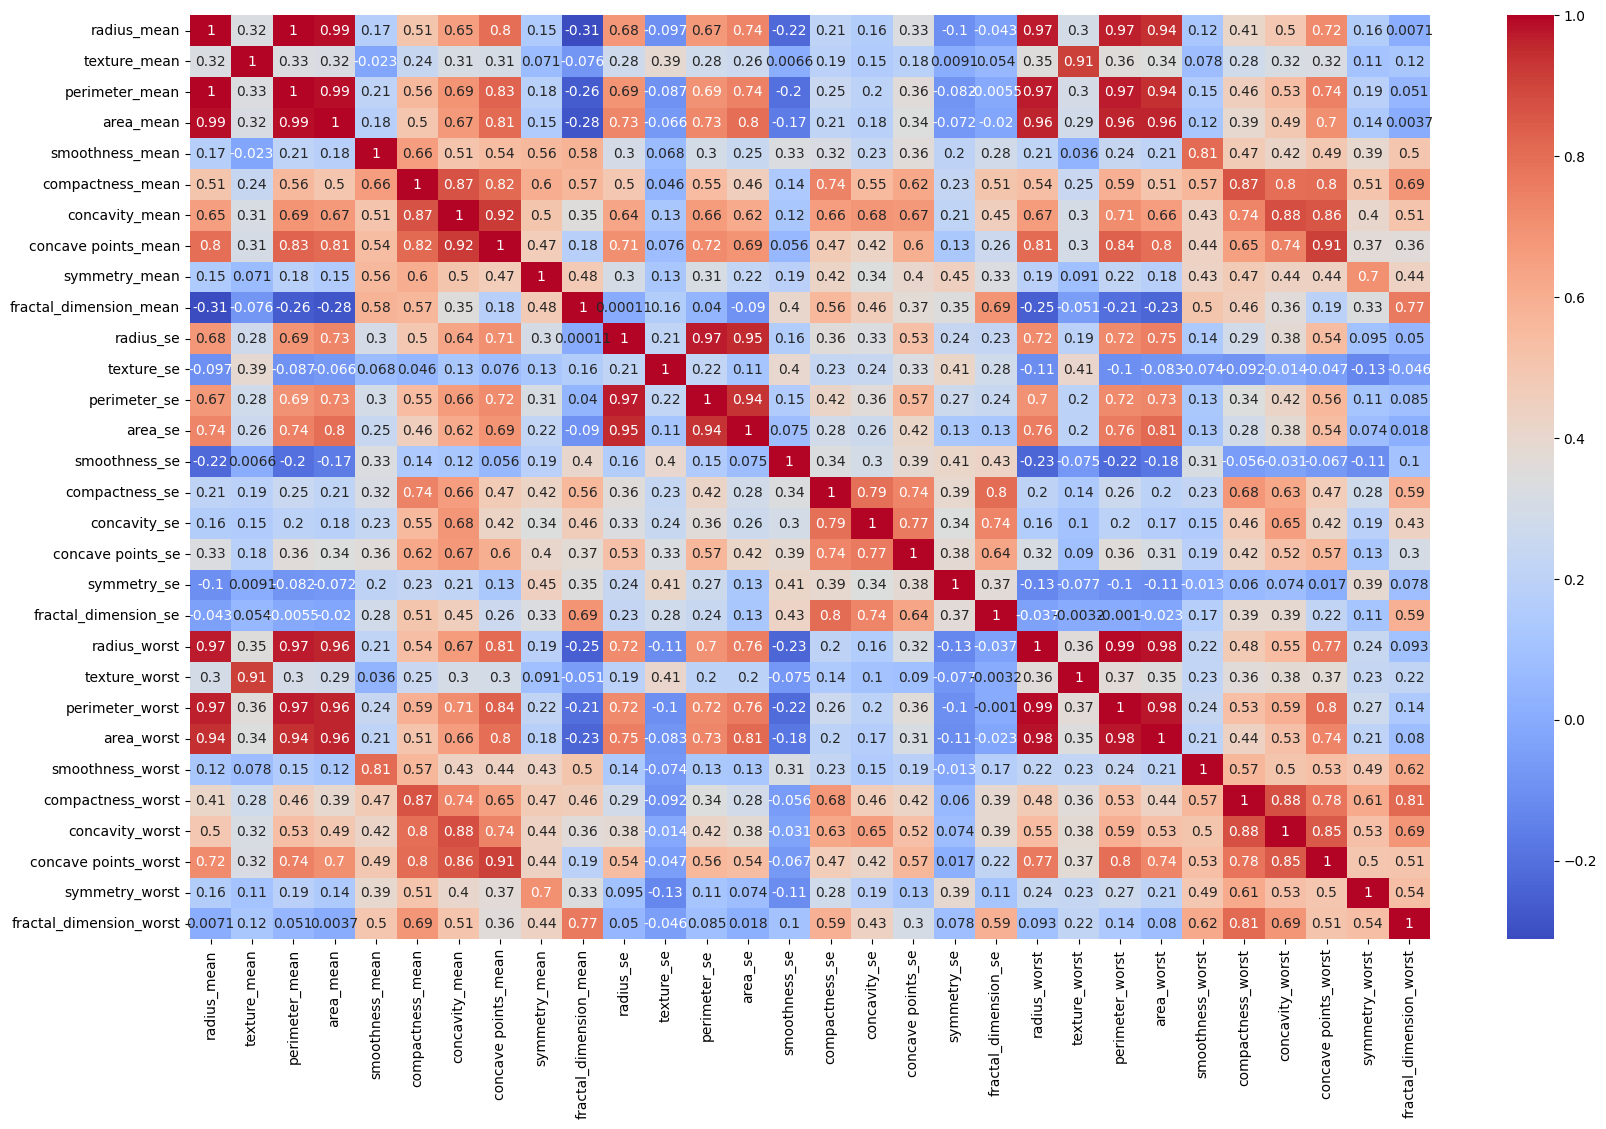

In [57]:
plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix,annot=True, cmap="coolwarm")
plt.show()

The correlation matrix shows strong relationships between many of the variables. This is especially clear for the size-related measurements, radius, perimeter, and area, and it holds across the mean, standard error, and worst versions of these variables. In fact, for radius, perimeter, and area, the mean and worst values are almost identical to each other statistically (r ≈ 0.96–0.97), meaning they largely capture the same information about tumor size. Concavity and compactness are also strongly correlated with each other. This much redundancy in the data confirms that a dimension reduction method is well suited here.

Texture variables are the exception: they show only weak correlations with the rest of the dataset, suggesting they capture something more independent of tumor size and shape.

The analysis uses the covariance matrix of the standardized variables, which lets us study the actual variability in the data while still accounting for how the variables relate to one another.

# Construction of the PCA and Selection of Axes

In [58]:
eig_val,eig_vect=np.linalg.eig(cov_matrix)
idx=np.argsort(eig_val)[::-1]
eig_val=eig_val[idx]
eig_vect=eig_vect[:,idx]

PCA is performed by diagonalizing the covariance matrix. The resulting eigenvalues are sorted in decreasing order, with each eigenvalue representing the proportion of variance explained by its associated axis.
Geometrically, the covariance matrix describes how much the data varies, and how the variables vary together, across all directions in the data space.

A projection onto a direction u maps each data point to a single number, calculated as proj = xᵀu. This number changes depending on which direction u we choose. Some directions give more spread-out values, others give values that are close together.
PCA looks for the direction u that gives the most spread, meaning the highest variance, among these projected values. This direction is the eigenvector of the covariance matrix with the largest eigenvalue.

Each eigenvector represents one possible direction to project the data onto. Its eigenvalue tells us how much variance the data has along that direction.

Since the covariance matrix is symmetric, its eigenvectors are always perpendicular to each other. This means the directions found by PCA don't overlap in the information they capture, so the resulting components are uncorrelated.

To reduce the number of dimensions, we keep only the directions (eigenvectors) with the largest eigenvalues and drop the ones with the smallest. This keeps most of the important variation in the data while removing directions that add little useful information.

In [59]:
# eig_vect = matrix of eigenvectors, columns = eigenvectors
n_axes = eig_vect.shape[1]
orthogonal_matrix = np.dot(eig_vect.T, eig_vect)
is_orthogonal = np.allclose(orthogonal_matrix, np.eye(n_axes))
print("The eigenvectors are orthogonal:", is_orthogonal)

The eigenvectors are orthogonal: True


This check confirms that the eigenvectors are orthogonal, a fundamental property of PCA that ensures the principal components are statistically and linearly independent (uncorrelated).

In [60]:
print(eig_val)

[13.163792  5.739183  2.858178  1.978984  1.600472  1.206507  0.663049
  0.482899  0.414974  0.370624  0.291248  0.26107   0.240292  0.214664
  0.101003  0.081642  0.059905  0.054144  0.051196  0.031582  0.029395
  0.028564  0.025302  0.01792   0.015626  0.00843   0.006881  0.00159
  0.000749  0.000135]


In [61]:
Inertia=eig_val.sum()
print('Total inertia: ', Inertia)

Total inertia:  29.99999999999997


As a general property in Linear Algebra, the sum of eigen value of a square matrix is the trace of, in this case the correlation matrix, which diagonal is composed of ones 

In [62]:
Axes_Ret=np.where(eig_val>=1)[0]
EigVal=eig_val[Axes_Ret]
EigVect=eig_vect[:,Axes_Ret]

As a criterion of selection for the eigen vectors we can use is the Kaiser criterion, which keeps only the axes whose eigen values are greater than 1.

In [63]:
Exp_Var=(EigVal)/sum(eig_val)
Inertcum=np.cumsum(Exp_Var)
print("Explained variances: \n",Exp_Var)
print("Cumulative inertia: \n",Inertcum)

Explained variances: 
 [0.438793 0.191306 0.095273 0.065966 0.053349 0.040217]
Cumulative inertia: 
 [0.438793 0.630099 0.725372 0.791338 0.844687 0.884904]


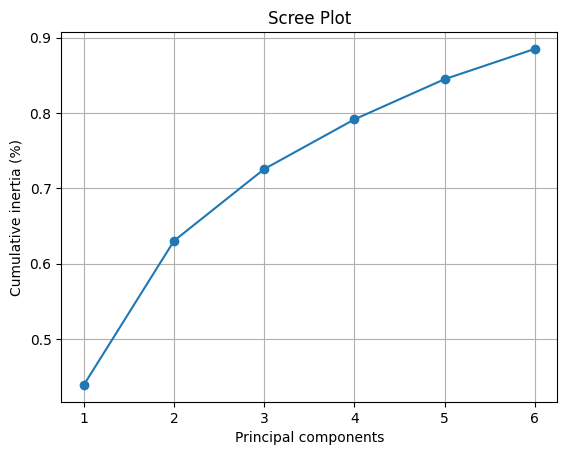

In [64]:
plt.plot(range(1, len(Inertcum)+1), Inertcum, 'o-')
plt.xlabel('Principal components')
plt.ylabel('Cumulative inertia (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(Inertcum)+1))
plt.grid(True)
plt.show()

According to this criterion, six axes are retained. These axes explain approximately 88.5% of the total variance, which indicates that nearly all of the information contained in the 30 original variables is preserved in a reduced-dimensional space.

By looking at the cumulative inertia of the selected axes, we observe that starting from the 3rd axis, more than 70% of the total variance is already represented, suggesting that 3 axes would be acceptable to represent all the data 

It may therefore be possible to reduce the data to just 3 axes. 

In [65]:
EigVal=EigVal[:6]
EigVect=EigVect[:,:6]
print(EigVal)
print('\n')
print(EigVect)

[13.163792  5.739183  2.858178  1.978984  1.600472  1.206507]


[[ 0.217444 -0.236638  0.009038 -0.041926  0.046544 -0.015902]
 [ 0.106711 -0.05801  -0.058735  0.595692 -0.101624  0.029467]
 [ 0.226224 -0.218182  0.010716 -0.043037  0.046778 -0.014122]
 [ 0.220499 -0.233064 -0.026789 -0.056301  0.021908  0.004876]
 [ 0.142733  0.180352  0.121098 -0.188398 -0.361745  0.274467]
 [ 0.239886  0.146214  0.086925 -0.040208  0.026242  0.020435]
 [ 0.257611  0.063217 -0.013367 -0.005183  0.083315  0.006339]
 [ 0.259827 -0.032866  0.013007 -0.058451 -0.050958  0.043679]
 [ 0.14037   0.186956  0.056462 -0.093378 -0.291379 -0.365441]
 [ 0.067296  0.363733  0.037858 -0.060218 -0.029253  0.125923]
 [ 0.208845 -0.104704 -0.256595 -0.114272 -0.146257  0.026271]
 [ 0.024987  0.097251 -0.364422  0.345866 -0.232181  0.020196]
 [ 0.214016 -0.088879 -0.254905 -0.103398 -0.113143  0.000134]
 [ 0.204683 -0.152202 -0.205827 -0.122565 -0.116329  0.044897]
 [ 0.018908  0.207344 -0.29541  -0.061674 -0.252634  0

## Projection of Individuals onto the Selected Axes 

Individuals are projected onto the principal axes through a linear combination of the standardized variables and their associated eigenvectors. Projecting onto the plane formed by the first two axes allows for a visualization of the structure of the data.

In [66]:
PC=df[cols] @ EigVect
PC.columns=["PC1","PC2","PC3","PC4","PC5","PC6"]
print(PC)


           PC1        PC2       PC3       PC4       PC5       PC6
0     9.251420   1.872189  1.317611 -3.803804 -0.617232 -1.363110
1     2.374240  -3.783770  0.461013 -1.069092  0.784268  0.003224
2     5.763983  -1.088480  0.532125 -0.919023 -0.052265 -0.552999
3     7.222818  10.166143  3.627424 -0.517495 -2.603475 -3.056117
4     3.945354  -1.926380 -1.468957 -2.866023  0.714961  1.231333
..         ...        ...       ...       ...       ...       ...
564   6.478004  -3.529073 -2.554775 -1.137995 -0.129990  2.341610
565   3.826888  -3.541285 -2.120797  2.479207 -0.783333  0.202662
566   1.255744  -1.872963 -0.660159  2.232572  1.597635  0.572160
567  10.445524   1.614284  2.030522  2.271833  0.019495 -0.535571
568  -3.591157   0.013976 -1.700280  2.301683  0.625922 -1.561412

[569 rows x 6 columns]


## Loadings

Let $X$ be the centred and normed data matrix, where rows are individuals and columns are variables.

The loadings are the projection of the variables onto the principal components. The loading of variable $j$ on component $s$ is the correlation between that variable and the individual scores on that component. It tells how strongly variable $j$ is linked to component $s$: a loading close to $1$ or $-1$ means the variable is well captured by that component, while a loading close to $0$ means it has little to do with it.

The $\sqrt{\lambda_s}$ factor that appears in the computation rescales the eigenvector coordinates by the importance of the axis: a dominant axis with a large eigenvalue stretches the projections further, giving larger loadings to the variables aligned with it.

This is what gets plotted on the correlation circle: each arrow represents a variable, and its direction and length show how well it is captured by the two displayed components.

In [67]:
loadings = EigVect * np.sqrt(EigVal)
loadings_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"],
    index=cols
)
print(loadings_df)

                              PC1       PC2       PC3       PC4       PC5  \
radius_mean              0.788929 -0.566903  0.015280 -0.058981  0.058883   
texture_mean             0.387170 -0.138972 -0.099298  0.837997 -0.128565   
perimeter_mean           0.820786 -0.522690  0.018116 -0.060544  0.059179   
area_mean                0.800015 -0.558343 -0.045290 -0.079203  0.027716   
smoothness_mean          0.517864  0.432063  0.204730 -0.265032 -0.457642   
compactness_mean         0.870354  0.350278  0.146957 -0.056563  0.033198   
concavity_mean           0.934661  0.151446 -0.022598 -0.007291  0.105401   
concave points_mean      0.942704 -0.078736  0.021990 -0.082226 -0.064467   
symmetry_mean            0.509290  0.447882  0.095456 -0.131360 -0.368624   
fractal_dimension_mean   0.244164  0.871380  0.064003 -0.084712 -0.037008   
radius_se                0.757732 -0.250835 -0.433803 -0.160753 -0.185030   
texture_se               0.090658  0.232981 -0.616098  0.486552 -0.293731   

## Visualization: Individual Projections and Correlation Circle

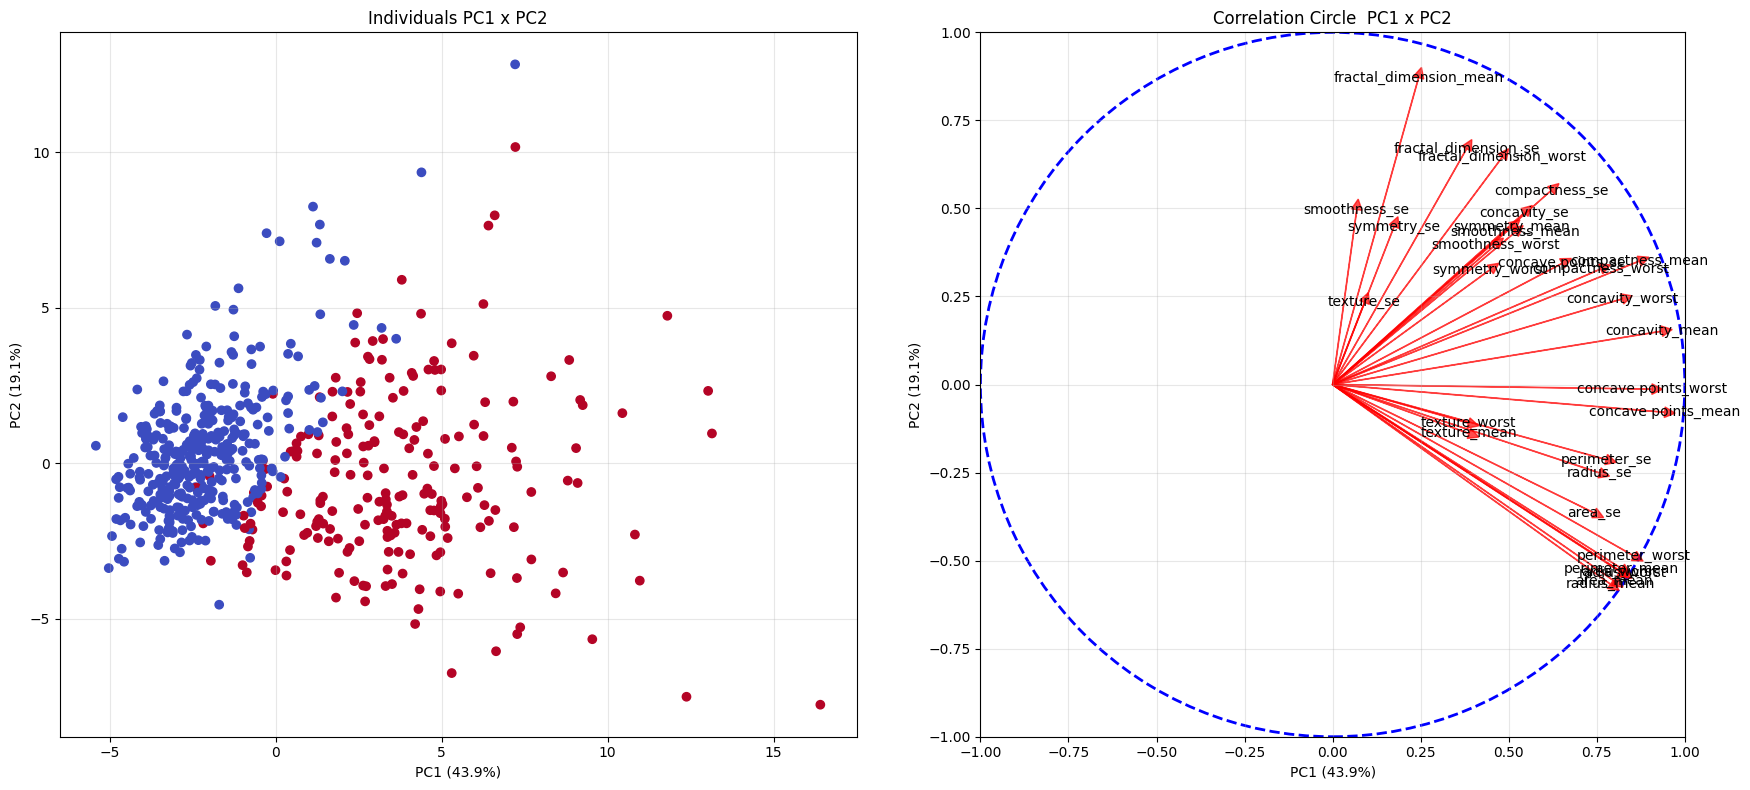

In [68]:
# Create a figure with 2 side-by-side subplots, 18x8 inches
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left plot: Individual projections ---

# Plot each individual as a dot, colored by diagnosis (red=malignant, blue=benign)
axes[0].scatter(PC.loc[:, 'PC1'], PC.loc[:, 'PC2'], c=(df["diagnosis"]=="M"), cmap="coolwarm")

# Label axes with component name and explained variance percentage
axes[0].set_xlabel(f'PC1 ({Exp_Var[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({Exp_Var[1]*100:.1f}%)')

# Title and light grid
axes[0].set_title('Individuals PC1 x PC2')
axes[0].grid(True, alpha=0.3)

# --- Right plot: Correlation circle ---

# Create a unit circle (radius=1) centered at origin, unfilled, blue dashed border
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=2)

# Attach the circle to the right subplot (it won't appear without this)
axes[1].add_patch(circle)

# For each variable, draw an arrow from origin to its loading coordinates
for var in cols:
    # Retrieve loading of this variable on PC1 and PC2
    x = loadings_df.loc[var, 'PC1']
    y = loadings_df.loc[var, 'PC2']

    # Draw red arrow from origin to (x, y)
    axes[1].arrow(0, 0, x, y, head_width=0.03, head_length=0.03, fc='red', ec='red', alpha=0.7)

    # Place variable name directly at the arrow tip
    axes[1].text(x, y, var, ha='center', va='center')

# Constrain axes to [-1, 1] since loadings are correlations bounded in this range
axes[1].set_xlim(-1.0, 1.0)
axes[1].set_ylim(-1.0, 1.0)

# Label axes and title
axes[1].set_xlabel(f'PC1 ({Exp_Var[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({Exp_Var[1]*100:.1f}%)')
axes[1].set_title('Correlation Circle  PC1 x PC2')
axes[1].grid(True, alpha=0.3)

# Force equal scaling so the circle appears round and not oval
axes[1].set_aspect('equal')

# Adjust spacing between subplots and render
plt.tight_layout()
plt.show()

This plane is the most important because it explains more than 63% of the total variance. The horizontal axis (PC1) mainly represents size and concavity variables, such as radius_mean, perimeter_mean, area_mean, concavity_mean, and concave points_mean. Their high values (close to 1) show that they are very well represented by PC1.

The vertical axis (PC2) mainly represents the fractal dimension variables, including fractal_dimension_mean, fractal_dimension_se, and fractal_dimension_worst, while the size variables are less well represented on this axis.

Together, PC1 and PC2 provide an excellent representation of the main variables. For example, perimeter_mean has a cumulative quality of 0.95, and radius_mean reaches 0.94.

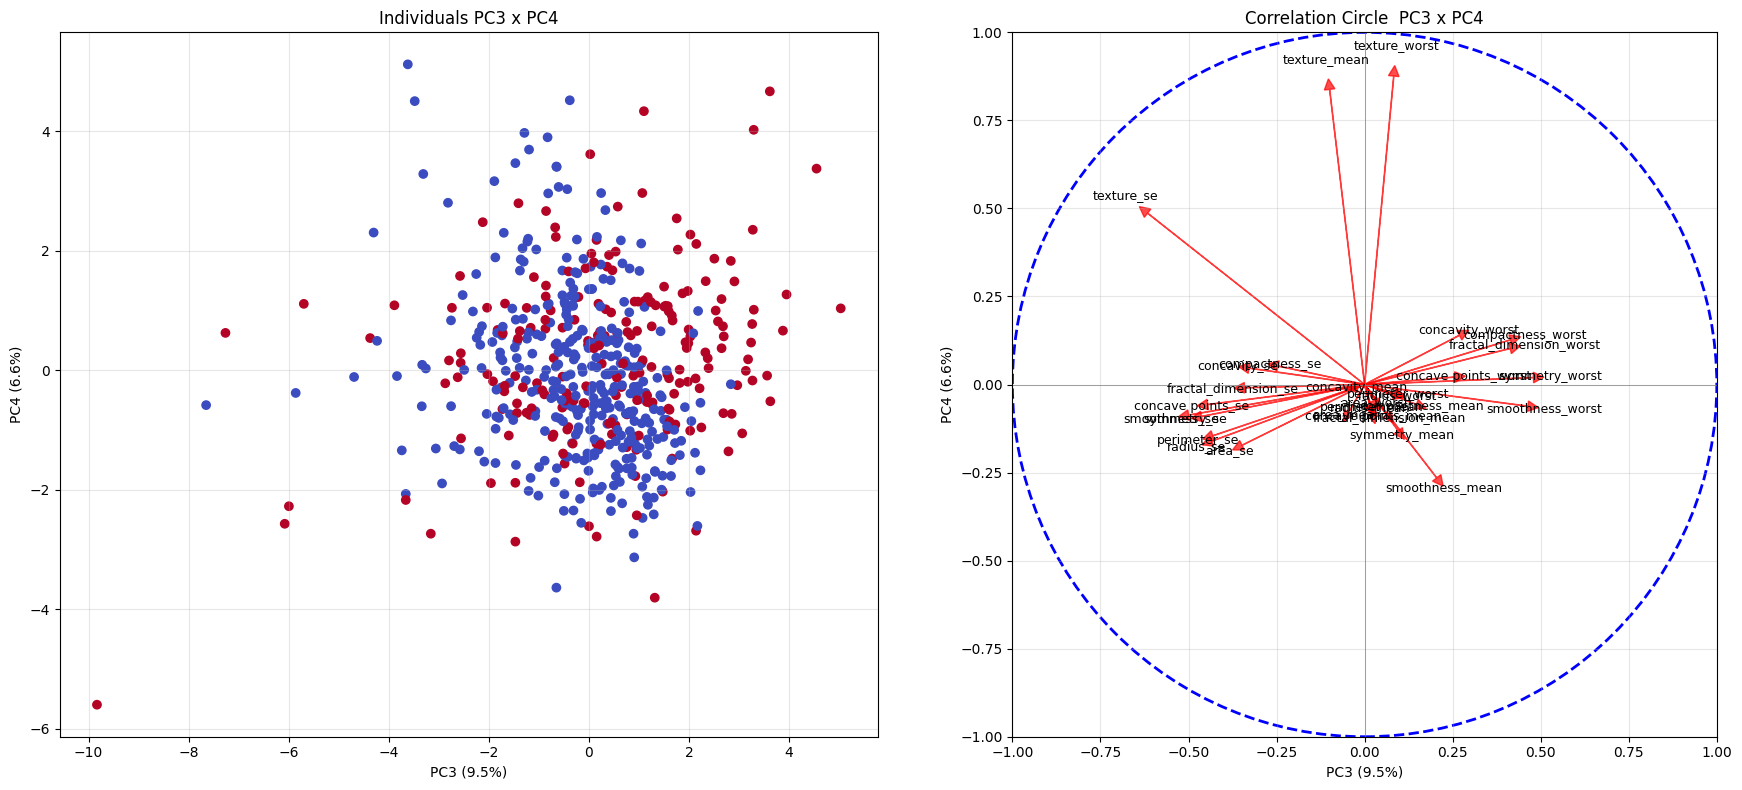

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].scatter(PC.loc[:, 'PC3'], PC.loc[:, 'PC4'], c=(df["diagnosis"]=="M"), cmap="coolwarm")
axes[0].set_xlabel(f'PC3 ({Exp_Var[2]*100:.1f}%)')
axes[0].set_ylabel(f'PC4 ({Exp_Var[3]*100:.1f}%)')
axes[0].set_title('Individuals PC3 x PC4')
axes[0].grid(True, alpha=0.3)

circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=2)
axes[1].add_patch(circle)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
for var in cols:
    x = loadings_df.loc[var, 'PC3']
    y = loadings_df.loc[var, 'PC4']
    axes[1].arrow(0, 0, x, y, head_width=0.03, head_length=0.03, fc='red', ec='red', alpha=0.7)
    axes[1].text(x * 1.1, y * 1.1, var, fontsize=9, ha='center', va='center')
axes[1].set_xlim(-1.0, 1.0)
axes[1].set_ylim(-1.0, 1.0)
axes[1].set_xlabel(f'PC3 ({Exp_Var[2]*100:.1f}%)')
axes[1].set_ylabel(f'PC4 ({Exp_Var[3]*100:.1f}%)')
axes[1].set_title('Correlation Circle  PC3 x PC4')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

PC3 and PC4 together add 16.1% of explained variance (9.5% and 6.6%), bringing the cumulative total to nearly 79% across the first four components.

PC3 is driven by variability and shape regularity measurements, mainly `texture_se`, `smoothness_se`, and `symmetry_se`, capturing how inconsistent the cell nuclei are across the tumor sample rather than their average size or shape. PC4 is almost entirely dominated by texture: `texture_worst` (loading ≈ 0.88) and `texture_mean` (loading ≈ 0.84) are by far the strongest contributors, isolating the grey-scale variation of cell nuclei in the biopsy image independently of size, compactness, or concavity. This confirms what was already visible in the correlation matrix: texture variables are largely uncorrelated with the rest of the dataset, and PC4 is the axis that finally captures them.

On the individual plot, the malignant/benign separation is noticeably weaker than on PC1 × PC2. This is expected, since size and concavity are the strongest discriminators between tumor types, and they are already fully captured by the first plane. On the correlation circle, size-related variables such as `radius_mean`, `perimeter_mean`, and `area_mean` have short arrows, confirming they contribute little here. Texture variables dominate this plane, with `texture_worst` and `texture_mean` reaching a cumulative $\cos^2$ of 0.77 and 0.71 on PC3 + PC4, meaning these two components are sufficient to almost fully represent texture information.

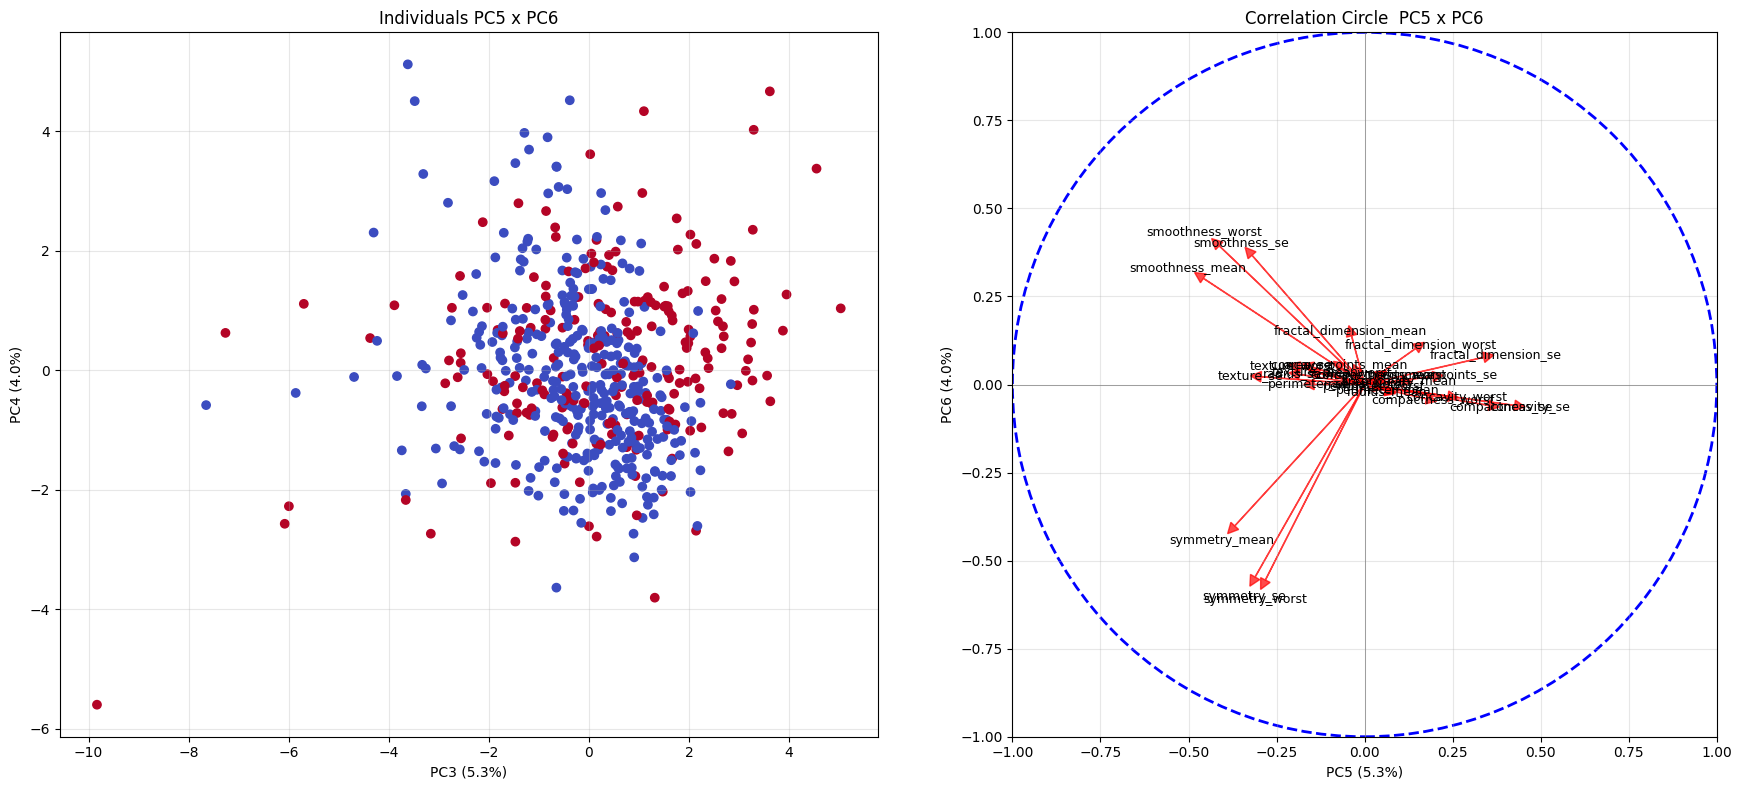

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].scatter(PC.loc[:, 'PC3'], PC.loc[:, 'PC4'], c=(df["diagnosis"]=="M"), cmap="coolwarm")
axes[0].set_xlabel(f'PC3 ({Exp_Var[4]*100:.1f}%)')
axes[0].set_ylabel(f'PC4 ({Exp_Var[5]*100:.1f}%)')
axes[0].set_title('Individuals PC5 x PC6')
axes[0].grid(True, alpha=0.3)

circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=2)
axes[1].add_patch(circle)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
for var in cols:
    x = loadings_df.loc[var, 'PC5']
    y = loadings_df.loc[var, 'PC6']
    axes[1].arrow(0, 0, x, y, head_width=0.03, head_length=0.03, fc='red', ec='red', alpha=0.7)
    axes[1].text(x * 1.1, y * 1.1, var, fontsize=9, ha='center', va='center')
axes[1].set_xlim(-1.0, 1.0)
axes[1].set_ylim(-1.0, 1.0)
axes[1].set_xlabel(f'PC5 ({Exp_Var[4]*100:.1f}%)')
axes[1].set_ylabel(f'PC6 ({Exp_Var[5]*100:.1f}%)')
axes[1].set_title('Correlation Circle  PC5 x PC6')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()



PC5 and PC6 are the last two retained axes, contributing 5.3% and 4.0% respectively, for a cumulative total of 88.5% across all six components.

PC5 captures a mix of smoothness and local shape irregularity, with `smoothness_mean`, `concavity_se`, `smoothness_worst`, and `symmetry_mean` as its main contributors. It reflects subtle variations in the local texture and boundary regularity of the nuclei that were not fully absorbed by the earlier components. PC6 is dominated by symmetry and smoothness in their worst-case measurements: `symmetry_worst` (loading ≈ 0.56) and `symmetry_se` (loading ≈ 0.55) are the strongest contributors, meaning this axis isolates the most extreme asymmetries observed across the tumor sample.

On the individual plot, the malignant/benign separation is very weak on this plane, as the information most relevant to diagnosis has already been captured by PC1 through PC4. On the correlation circle, most variables have short arrows, reflecting that they are already well explained by the previous axes. The variables best represented here are symmetry and smoothness related ones, with `symmetry_se` and `symmetry_worst` reaching a cumulative $\cos^2$ of 0.40 and 0.39 on PC5 + PC6.


In [71]:
# Compute cos2 as the square of each loading
cos2 = loadings_df ** 2

# Cumulative cos2 across all 6 axes per variable, sorted descending
cos2_cumul = cos2.sum(axis=1).sort_values(ascending=False)

print(cos2.round(3))
print('\nCumulative cos2:')
print(cos2_cumul.round(3))

                           PC1    PC2    PC3    PC4    PC5    PC6
radius_mean              0.622  0.321  0.000  0.003  0.003  0.000
texture_mean             0.150  0.019  0.010  0.702  0.017  0.001
perimeter_mean           0.674  0.273  0.000  0.004  0.004  0.000
area_mean                0.640  0.312  0.002  0.006  0.001  0.000
smoothness_mean          0.268  0.187  0.042  0.070  0.209  0.091
compactness_mean         0.758  0.123  0.022  0.003  0.001  0.001
concavity_mean           0.874  0.023  0.001  0.000  0.011  0.000
concave points_mean      0.889  0.006  0.000  0.007  0.004  0.002
symmetry_mean            0.259  0.201  0.009  0.017  0.136  0.161
fractal_dimension_mean   0.060  0.759  0.004  0.007  0.001  0.019
radius_se                0.574  0.063  0.188  0.026  0.034  0.001
texture_se               0.008  0.054  0.380  0.237  0.086  0.000
perimeter_se             0.603  0.045  0.186  0.021  0.020  0.000
area_se                  0.552  0.133  0.121  0.030  0.022  0.002
smoothness

## Quality of Representation

The quality of representation of a variable on a given component is measured by the $\cos^2$, which is the square of its loading. It ranges from 0 to 1 and tells what fraction of the variable's variance is captured by that component. A $\cos^2$ close to 1 means the variable is well captured by that axis; close to 0 means it carries little information on it.

The cumulative $\cos^2$ across all six retained axes reflects how well the variable is represented overall in the reduced space. The best represented variables are `perimeter_worst` (0.978), `radius_worst` (0.972), and `texture_worst` (0.972), all exceeding 97%. The least represented are `smoothness_se` (0.745) and `texture_se` (0.766), whose variance is spread across many directions and harder to concentrate in a few axes.

In [72]:
# Compute contribution of each variable to each axis
# = share of the axis's eigenvalue explained by that variable
contrib = pd.DataFrame()
for i, col in enumerate(["PC1","PC2","PC3","PC4","PC5","PC6"]):
    contrib[col] = (loadings_df[col]**2) / EigVal[i]

print(contrib.round(2))

                          PC1   PC2   PC3   PC4   PC5   PC6
radius_mean              0.05  0.06  0.00  0.00  0.00  0.00
texture_mean             0.01  0.00  0.00  0.35  0.01  0.00
perimeter_mean           0.05  0.05  0.00  0.00  0.00  0.00
area_mean                0.05  0.05  0.00  0.00  0.00  0.00
smoothness_mean          0.02  0.03  0.01  0.04  0.13  0.08
compactness_mean         0.06  0.02  0.01  0.00  0.00  0.00
concavity_mean           0.07  0.00  0.00  0.00  0.01  0.00
concave points_mean      0.07  0.00  0.00  0.00  0.00  0.00
symmetry_mean            0.02  0.03  0.00  0.01  0.08  0.13
fractal_dimension_mean   0.00  0.13  0.00  0.00  0.00  0.02
radius_se                0.04  0.01  0.07  0.01  0.02  0.00
texture_se               0.00  0.01  0.13  0.12  0.05  0.00
perimeter_se             0.05  0.01  0.06  0.01  0.01  0.00
area_se                  0.04  0.02  0.04  0.02  0.01  0.00
smoothness_se            0.00  0.04  0.09  0.00  0.06  0.11
compactness_se           0.03  0.05  0.0

## Contributions

The contribution of a variable to a component measures how much that variable pulled that axis in its direction during the diagonalization. Unlike the $\cos^2$, which is read from the variable's perspective, the contribution is read from the axis's perspective: it tells which variables built it. The contributions sum to 100% for each axis, and a variable contributing above $\frac{100}{p} = 3.33\%$ is considered an above-average contributor for 30 variables.

PC1 is built mostly by concavity and size variables: `concave_points_mean` (6.75%), `concavity_mean` (6.64%), `concave_points_worst` (6.24%), and `perimeter_worst` (5.56%). PC2 is largely driven by fractal dimension: `fractal_dimension_mean` (13.23%), `fractal_dimension_se` (7.81%), and `fractal_dimension_worst` (7.26%). PC3 is pulled by `texture_se` (13.28%) and `smoothness_se` (8.73%). PC4 is almost entirely built by texture: `texture_worst` (38.76%) and `texture_mean` (35.48%) together account for over 74% of this axis. PC5 and PC6 have their contributions spread more evenly across smoothness, symmetry, and concavity standard error variables.

## Interpretation Summary

The six retained components each summarize a different source of variation in the data.

PC1 (43.9%) is the dominant axis. It groups together all size and shape variables — radius, perimeter, area, concavity, and compactness — which are highly correlated with each other. A high score on PC1 simply means the tumor is large and irregularly shaped, and since malignant tumors tend to be both, this axis is the one that separates the two groups most clearly.

PC2 (19.1%) is orthogonal to PC1 and picks up what PC1 missed: the fractal dimension variables, which measure boundary irregularity independently of size. Two tumors can have the same size but very different boundary complexity, and PC2 captures exactly that difference.

PC3 (9.5%) captures variability within the sample rather than average measurements. It is driven by standard error variables — texture_se, smoothness_se, symmetry_se — meaning it reflects how inconsistent the nuclei measurements are across a given tumor.

PC4 (6.6%) is almost entirely built by the two texture variables, which are weakly correlated with everything else in the dataset. This orthogonality is why texture ends up isolated on its own axis rather than mixed into the earlier components.

PC5 (5.3%) and PC6 (4.0%) absorb the remaining variance in smoothness and symmetry that was not captured by the previous axes, and carry little discriminating power between the two diagnostic groups.

## Role of Size in Tumor Diagnosis

Among all variables in the dataset, size-related ones such as `radius_mean`, `perimeter_mean`, `area_mean`, and their worst-case counterparts have the highest loadings on PC1, which is also the axis that separates malignant from benign cases most clearly. This is not a coincidence: it means that the direction of maximum variance in the data is the same as the direction that best separates the two groups.

Size does not act alone . In this dataset, larger tumors also tend to be more concave and more compact, meaning these variables are correlated and all point in the same direction in the variable space. PC1 captures this joint structure as a single axis, which is why so many different variables load heavily onto it at the same time.

A worst-case measurement records the largest value observed across all nuclei in a tumor, so it widens the differences between tumors that are already visible in the mean measurements. Malignant tumors tend to be more variable internally, so their worst-case values differ more from the benign ones than their means do.